# R01 figures

Figures for the R01 renewal.  Each section below builds one panel-figure and
writes it to `Figures_opcond_R01/`.

## Aim 3.2 — Reflex reversal

Replicates `Figure_Aim2_2_ReflexReversal` from the 2021 application (that one
was Aim 2.2; here the same result becomes **Aim 3.2**).

The MATLAB original is the "Aim 2.2 reflex reversal" cell of
`FlyAnalysis/Records/P2_Reaching/Scripts/Script_R01figures_211014.m`, which
calls `Script_PlotTargetTriggeredStimuli.m`.  The measurements it made now live
in `mapd.target_triggered`; this notebook only arranges them.

**The design.** In `LEDFlashTriggerPiezoControl` every trial delivers the *same*
mechanical stimulus twice: once as a **cue** at a fixed time in the pre-period,
before the aversive stimulus (AS) comes on, and once as a **target-triggered
stimulus**, fired by the Arduino at the instant the fly reaches the target and
the AS goes off.  The cue response is the reflex at rest; the triggered
response is the reflex during an ongoing reach.  Comparing them is the whole
point of the figure.

Cell `210903_F3_C1`, neuron F1.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import mapd
from mapd import target_triggered as tt


HICLR, LOCLR = (1.0, .35, 1.0), (.45, 0, .45)
STIMCLR, ASCLR = (.10, .20, .70), (.62, .05, .10)
BANDCLR = (1, .87, .92)
plt.rcParams.update({'font.size': 10, 'axes.linewidth': 1.0})
import os

### Configuration

`LARGE` / `SMALL` are the two flexion steps.  They are `displacement = +5` and
`+2.5`, i.e. the two that drive `sgsmonitor` **up** from its 5 V background.

A note on the MATLAB, because it looks like it disagrees: the old script picked
its trials with `displacement==5` / `displacement==2.5` out of the *MeasureTable*
and detected the ramp with the threshold pairs `[4.5 3]` / `[5.5 7]`.  The first
pair only crosses on a **downward** step, so the MeasureTable's `displacement`
does not carry the same sign as `params.displacement` does here.  Those
thresholds encode direction only, not amplitude, so they cannot settle which
step is which.  The data can: `+5` is the only condition whose *cue* response
shows the deep firing-rate trough that panel B reproduces, and `+2.5` is the
only one with enough low-force trials (8) to split panel C.  Both are upward
(flexion) steps, which is how the published cartoons draw them.

In [3]:
CELL = '210903_F3_C1'
EXAMPLE_TRIAL = 493
LARGE, SMALL = 5.0, 2.5
XL, XR = -0.10, 0.80          # display window (see below)
FIGDIR = 'Figures_opcond_R01'

### Trials

The panels use `as_outcome == 'as_off'` — trials in which the fly reached the
target and switched the aversive stimulus off, which is what causes a stimulus
to be triggered.  This is outcome 3 in the MATLAB `MeasureTable`, the same set.
Trial 381 is dropped, as in the original.

In [4]:
T = mapd.Table(f"D:/Data/210903/{CELL}/LEDFlashTriggerPiezoControl_{CELL}_Table.parquet")
df = T.df[T.df.as_outcome == 'as_off'].copy()
df['trialnum'] = [int(x.params['trial']) for x in df['Trial']]
df = df[df.trialnum != 381]

sets = {}
for name, disp in (('large', LARGE), ('small', SMALL)):
    sub = df[df.displacement == disp]
    a = tt.align_trials(list(sub['Trial']))
    a['pyas'] = np.asarray(sub['pyasState'])
    sets[name] = a

print(df.groupby(['displacement', 'pyasState'], observed=True).size())

Found data directory: D:\Data
T = pd.read_parquet("D:\\Data\\210903\\210903_F3_C1\\LEDFlashTriggerPiezoControl_210903_F3_C1_Table.parquet")
Getting trials


Excluding trials:
[]
Getting all meta keys
['as_outcome', 'fiberLED', 'filtercube_status', 'probeZero', 'pyasState', 'pyasWidth', 'pyasXPosition']


Found 2 target positions - Counter({('hi', 732.0, 452.0, -280.0, 60.0): 474, ('lo', 732.0, 552.0, -180.0, 60.0): 126})


displacement  pyasState
-5.0          lo            1
              hi           18
-2.5          lo            2
              hi           17
 2.5          lo            8
              hi           16
 5.0          lo            1
              hi           15
dtype: int64


### Checking the alignment

The published right-hand column is labelled *aligned to AS off*, but what the
MATLAB actually aligned to was the extrapolated onset of the triggered piezo
ramp.  Those are not the same event, so it is worth knowing the offset between
them before trusting the label.

The cell below measures both, and also measures the same lag on the **cue**,
whose commanded onset is known exactly from the protocol definition.

In [5]:
lags = []
for _, r in df.iterrows():
    trial_ = r['Trial']
    lags.append((tt.triggered_stim_onset(trial_) - tt.as_off_time(trial_)) * 1e3)
lags = np.array(lags)
t_ref = df.iloc[0]['Trial']
ptd = t_ref.params['posttriggerdelay'] * 1e3
t_ref.downsample_probe          # populates frame_length_mode
frame = t_ref.frame_length_mode / t_ref.params['sampratein'] * 1e3

print(f'AS off -> triggered ramp onset : {lags.mean():6.3f} +/- {lags.std():.3f} ms  (n={len(lags)})')
print(f'commanded posttriggerdelay     : {ptd:6.3f} ms')
print(f'residual                       : {lags.mean() - ptd:6.3f} ms')
print(f'probe-tracking frame           : {frame:6.3f} ms  ({1e3 / frame:.0f} fps)')

AS off -> triggered ramp onset : 53.146 +/- 0.089 ms  (n=78)
commanded posttriggerdelay     : 50.000 ms
residual                       :  3.146 ms
probe-tracking frame           :  5.000 ms  (200 fps)


The triggered ramp starts **53.1 ms** after the LED goes off, with a jitter of
0.09 ms — less than five samples at 50 kHz.  Of that, 50.0 ms is the commanded
`posttriggerdelay`; the remaining **3.1 ms** is the piezo plus strain-gauge
monitor, and the same ~2.8 ms lag shows up on the cue, whose trigger comes from
the analog output rather than from the Arduino.

So the Arduino drops the LED and fires the piezo in the same pass — there is no
measurable decision latency between them, and *aligned to AS off* and *aligned
to the stimulus* differ only by a fixed 53 ms.  In particular this residual is
**not** a frame quantum: the probe tracker runs at 200 fps (5.00 ms/frame), and
a frame-quantised delay would jitter over a whole frame instead of over
0.09 ms.  Frame quantisation does enter the *reach-to-AS-off* latency, which is
what the tracker decides; it does not enter AS-off-to-stimulus.

### Cutting the windows

`align_trials` returns a cue-aligned and a trigger-aligned window per trial,
0.2 s of baseline plus the 0.8 s of the MATLAB `cuewin`.

In [6]:
sets = {}
for name, disp in (('large', LARGE), ('small', SMALL)):
    sub = df[df.displacement == disp]
    a = tt.align_trials(list(sub['Trial']))
    a['pyas'] = np.asarray(sub['pyasState'])
    sets[name] = a
    print(f"{name:5s} disp={disp:+.1f}  n={len(sub):2d} "
          f"(hi {np.sum(a['pyas'] == 'hi')}, lo {np.sum(a['pyas'] == 'lo')})")

large disp=+5.0  n=16 (hi 15, lo 1)


small disp=+2.5  n=24 (hi 16, lo 8)


Panels are drawn from `XL = -0.10 s` rather than from the full `-0.20 s`.  The
cue sits only 0.8 s into the trial, so its window starts at the very first
sample of the recording, where the spike detector has not yet filled its
template window and finds nothing — across the 16 large-step trials there is
not one spike in the first 10 ms.  Rate estimates over that stretch are an
artefact of detection, not a silent period, so they are cropped rather than
plotted.  (`firing_rate` also defaults to `edge='normalize'`, which divides by
the width of the window that actually exists; pass `edge='matlab'` for the
literal `firingRate.m` behaviour, which ramps up from zero.)

In [7]:
def bare(ax):
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
    return ax


def yscale_bar(ax, x, y0, y1, label):
    tick = 0.020 * (ax.get_xlim()[1] - ax.get_xlim()[0])
    ax.plot([x, x], [y0, y1], color='k', lw=1.6, clip_on=False)
    for y in (y0, y1):
        ax.plot([x, x + tick], [y, y], color='k', lw=1.6, clip_on=False)
        ax.text(x - .6 * tick, y, f'{y:g}', ha='right', va='center')
    ax.text(x - 4.2 * tick, (y0 + y1) / 2, label, ha='center', va='center', rotation=90)


def flex_arrow(ax, x, y, dy, label=True):
    ax.annotate('', xy=(x, y + dy), xytext=(x, y),
                arrowprops=dict(color=STIMCLR, width=1.3, headwidth=6, headlength=6))
    if label:
        ax.text(x - .012 * (ax.get_xlim()[1] - ax.get_xlim()[0]), y, 'flex',
                color=STIMCLR, ha='right', va='center')

### The figure

In [8]:
fig = plt.figure(figsize=(6.6, 10.2))
gs = fig.add_gridspec(
    12, 2,
    height_ratios=[1.15, 1.45, .55, .40, .70, 1.30, 1.10, .62, .70, 1.90, 1.10, .10],
    hspace=.0, wspace=.26, left=.115, right=.985, top=.965, bottom=.015)

# --- panel A --------------------------------------------------------

row = df[df.trialnum == EXAMPLE_TRIAL].iloc[0]
trial = row['Trial']
onset = tt.triggered_stim_onset(trial)
as_off = tt.as_off_time(trial)
t = trial.trialtime
n = len(t)
t0, t1 = -1.05, onset + 0.72
m = (t >= t0) & (t <= t1)
sgs = np.asarray(trial.sgsmonitor).ravel()[:n]
ard = np.asarray(trial.arduino_output).ravel()[:n]
pz = trial.probeZero
probe = -(np.asarray(trial.probe_position).ravel()[:n] - pz)
tl = trial.params['target_location']
# target_location is [x, width] in raw camera coordinates, so the zone is
# raw [x, x + width].  The display transform -(raw - probeZero) flips the
# sign, which puts the zone's far edge *below* -(x - probeZero).
tgt_hi = -(tl[0] - pz)
tgt_lo = tgt_hi - tl[1]

axA1 = bare(fig.add_subplot(gs[0, :]))
axA1.set_xlim(t0, t1); axA1.set_ylim(-0.10, 3.00)
axA1.plot(t[m], (sgs[m] - np.median(sgs[m])) / 2.5 * 0.55 + 1.10, color=STIMCLR, lw=1.5)
axA1.plot(t[m], ard[m] * 0.52, color=ASCLR, lw=1.5)
axA1.annotate('', xy=(as_off, 0.68), xytext=(as_off, 1.62),
              arrowprops=dict(color=ASCLR, width=1.5, headwidth=7, headlength=7))
axA1.text(as_off, 1.68, 'AS off', color=ASCLR, ha='center', va='bottom', fontsize=12)
axA1.text(-0.80, 1.62, 'mech. stimulus', color=STIMCLR, ha='left', va='bottom', fontsize=12)
axA1.text(t1, 1.62, 'Triggered stim', color=STIMCLR, ha='right', va='bottom', fontsize=12)
axA1.text(-0.86, 0.56, 'LED (AS)', color=ASCLR, ha='left', va='bottom', fontsize=12)
flex_arrow(axA1, t0 + .015, 1.10, 0.55)
axA1.text(.085, 1.04, 'Example reaching trial', transform=axA1.transAxes,
          ha='left', va='top', fontsize=13)
axA1.text(-.10, 1.06, 'A', transform=axA1.transAxes, ha='left', va='top',
          fontsize=16, fontweight='bold')

axA2 = bare(fig.add_subplot(gs[1, :]))
axA2.set_xlim(t0, t1)
band = tgt_hi - tgt_lo
lo_y = min(probe[m].min(), tgt_lo) - 0.25 * band
hi_y = max(probe[m].max(), tgt_hi) + 0.05 * band
axA2.set_ylim(lo_y, hi_y)
axA2.axhspan(tgt_lo, tgt_hi, color=BANDCLR, zorder=0)
axA2.plot(t[m], probe[m], color='k', lw=1.1)
axA2.text(t0 + .13, tgt_hi - .04 * (hi_y - lo_y), 'Probe position',
          ha='left', va='top', fontsize=12)
axA2.text(t0 - .105, (tgt_lo + tgt_hi) / 2, 'High\nforce', color=LOCLR, ha='center',
          va='center', fontsize=12, rotation=90, linespacing=.85)
axA2.plot([t0 - .025] * 2, [tgt_lo, tgt_hi], color='k', lw=1.4, clip_on=False)
sb0 = t1 - 0.34
sb_y = lo_y + 0.22 * (hi_y - lo_y)
axA2.plot([sb0, sb0 + 0.3], [sb_y] * 2, color='k', lw=4)
axA2.text(sb0 + 0.15, sb_y - .03 * (hi_y - lo_y), '300 ms', ha='center', va='top',
          fontsize=12)

axA3 = bare(fig.add_subplot(gs[2, :]))
spk = trial.time[np.asarray(trial.spikes).ravel().astype(int) - 1]
spk = spk[(spk >= t0) & (spk <= t1)]
axA3.eventplot(spk, colors='k', lineoffsets=0.78, linelengths=.34, linewidths=1.0)
axA3.set_xlim(t0, t1); axA3.set_ylim(0, 1.0)
axA3.text(t0 + .03, 0.50, 'F1 spike raster', ha='left', va='top', fontsize=12);

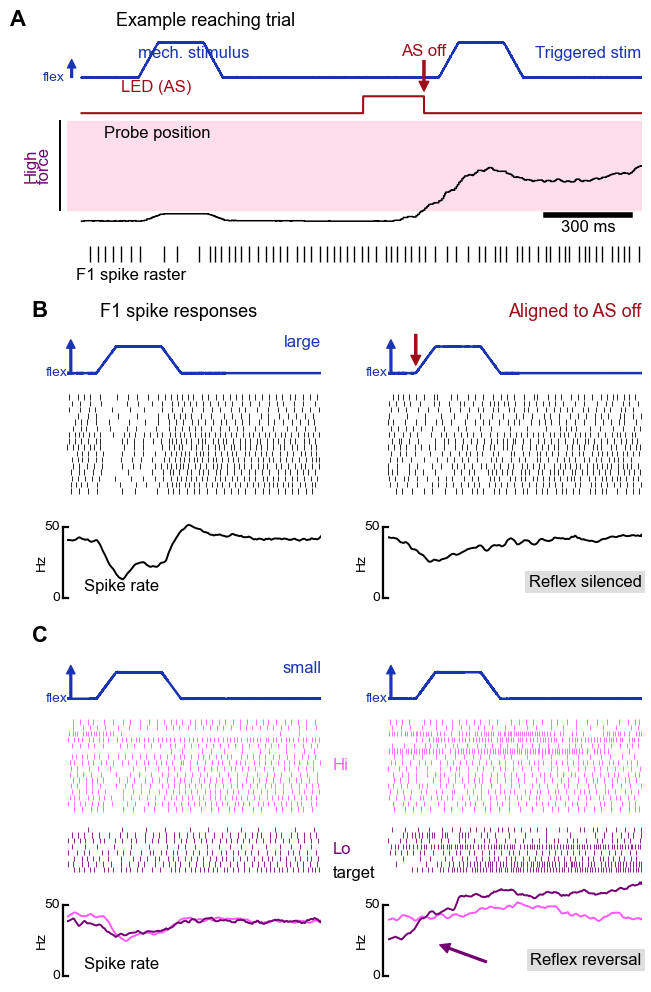

In [9]:
# --- panels B and C -------------------------------------------------

def stim_panel(a, r0, split, letter, size_label, headers):
    tw = a['t']
    keep = (tw >= XL) & (tw <= XR)
    out = []
    for c, key in enumerate(('cue', 'stim')):
        d = a[key]
        good = np.isfinite(d['onset'])
        ax_s = bare(fig.add_subplot(gs[r0, c]))
        ax_r = bare(fig.add_subplot(gs[r0 + 1, c]))
        ax_f = fig.add_subplot(gs[r0 + 2, c])
        out.append((ax_s, ax_r, ax_f))

        s = np.nanmean(d['sgs'][good], axis=0)
        s = s - np.median(s[keep])
        amp = np.nanmax(s[keep])
        ax_s.set_xlim(XL, XR); ax_s.set_ylim(-0.55 * amp, 1.75 * amp)
        ax_s.plot(tw[keep], s[keep], color=STIMCLR, lw=1.8)
        flex_arrow(ax_s, XL + .012, 0, 1.25 * amp)
        if c == 0:
            ax_s.text(XR, 1.15 * amp, size_label, color=STIMCLR, ha='right',
                      va='center', fontsize=12)
            ax_s.text(-.14, 1.10, letter, transform=ax_s.transAxes, ha='left',
                      va='bottom', fontsize=16, fontweight='bold')
        if headers[c]:
            ax_s.text(.13 if c == 0 else 1, 1.10, headers[c], transform=ax_s.transAxes,
                      ha='left' if c == 0 else 'right', va='bottom', fontsize=13,
                      color='k' if c == 0 else ASCLR)
        if c == 1 and letter == 'B':
            ax_s.annotate('', xy=(0, .30 * amp), xytext=(0, 1.45 * amp),
                          arrowprops=dict(color=ASCLR, width=1.5, headwidth=7, headlength=7))

        groups = [('hi', HICLR), ('lo', LOCLR)] if split else [(None, 'k')]
        y, marks = 0.0, []
        for g, clr in groups:
            sel = good if g is None else (good & (a['pyas'] == g))
            y0 = y
            for r in np.flatnonzero(sel):
                st = tw[d['raster'][r]]
                ax_r.eventplot(st[(st >= XL) & (st <= XR)], colors=[clr],
                               lineoffsets=y, linelengths=.9, linewidths=.6)
                y += 1
            marks.append((g, clr, (y0 + y - 1) / 2))
            y += 2.5
            ax_f.plot(tw[keep], tt.firing_rate(tw, d['raster'][sel])[keep],
                      color=clr, lw=1.4)
        ax_r.set_xlim(XL, XR); ax_r.set_ylim(y - 1.8, -1.5)   # first group on top
        if split and c == 0:
            for g, clr, ym in marks:
                ax_r.text(XR + .04, ym, 'Hi' if g == 'hi' else 'Lo', color=clr,
                          ha='left', va='center', fontsize=12)
            ax_r.text(XR + .04, marks[1][2] + 4.0, 'target', color='k',
                      ha='left', va='center', fontsize=12)

        ax_f.set_xlim(XL, XR); ax_f.set_ylim(0, 68)
        bare(ax_f)
        yscale_bar(ax_f, XL - .015, 0, 50, 'Hz')
        if c == 0:
            ax_f.text(XL + .06, 3, 'Spike rate', ha='left', va='bottom', fontsize=12)
    return out


axB = stim_panel(sets['large'], 4, False, 'B', 'large',
                 ('F1 spike responses', 'Aligned to AS off'))
axC = stim_panel(sets['small'], 8, True, 'C', 'small', (None, None))

for ax, txt in ((axB[1][2], 'Reflex silenced'), (axC[1][2], 'Reflex reversal')):
    ax.text(XR, 6, txt, ha='right', va='bottom', fontsize=12,
            bbox=dict(boxstyle='square,pad=.22', fc=(.87, .87, .87), ec='none'))
axC[1][2].annotate('', xy=(0.085, 22), xytext=(0.25, 10),
                   arrowprops=dict(color=LOCLR, width=1.3, headwidth=7, headlength=7))

fig

In [10]:
os.makedirs(FIGDIR, exist_ok=True)
for ext in ('png', 'pdf', 'svg'):
    fig.savefig(os.path.join(FIGDIR, f'Figure_Aim3_2_ReflexReversal.{ext}'),
                dpi=300, facecolor='w')
print(f'saved {FIGDIR}/Figure_Aim3_2_ReflexReversal.' + '{png,pdf,svg}')

saved Figures_opcond_R01/Figure_Aim3_2_ReflexReversal.{png,pdf,svg}


### What the panels show

* **B (large step).** At rest the stimulus drives a deep pause — the rate falls
  from ~40 Hz to ~15 Hz and then overshoots to ~50 Hz.  Delivered during a
  reach, the identical stimulus does essentially nothing: the reflex is
  **silenced**.
* **C (small step).** The same comparison, split by target.  On high-force
  trials (pink) the triggered response stays flat.  On low-force trials
  (purple) the neuron is *driven up* by a stimulus that pauses it at rest —
  the reflex has **reversed** sign.